<a href="https://colab.research.google.com/github/Shawnpeter578/practise_ML/blob/main/multipleLR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [3]:
df_index = pd.read_csv('/content/economic_index (2).csv')

In [4]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [5]:
df_index.drop(columns=['Unnamed: 0', 'year','month'], axis=1, inplace=True)

In [6]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [8]:
df_index.isnull().sum()

,0
interest_rate,0
unemployment_rate,0
index_price,0


In [9]:
df_index.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   interest_rate      24 non-null     float64
 1   unemployment_rate  24 non-null     float64
 2   index_price        24 non-null     int64  
dtypes: float64(2), int64(1)
memory usage: 708.0 bytes


In [10]:
import seaborn as sns

In [11]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


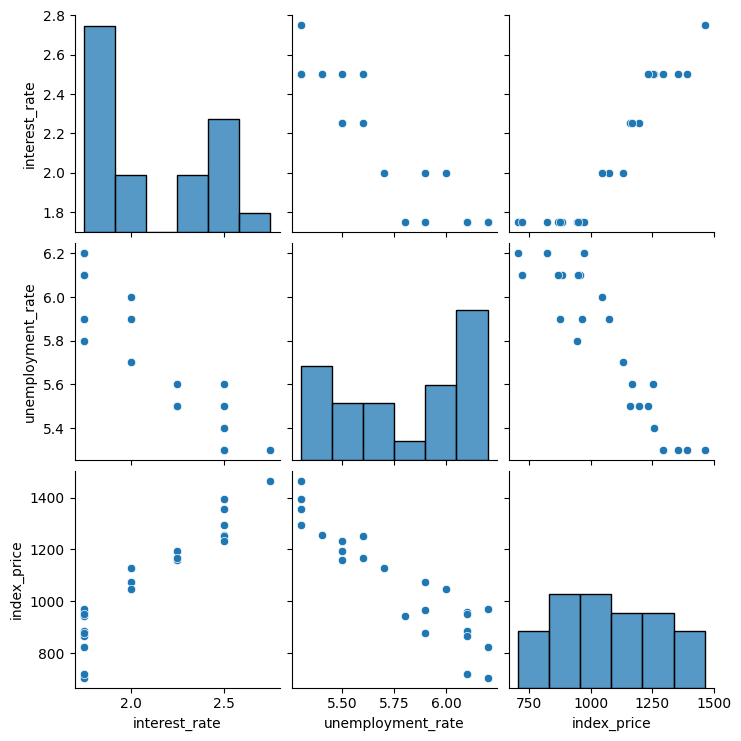

In [12]:
sns.pairplot(df_index)

## visualize the datapoints

Text(0, 0.5, 'Unemployemnt rate')

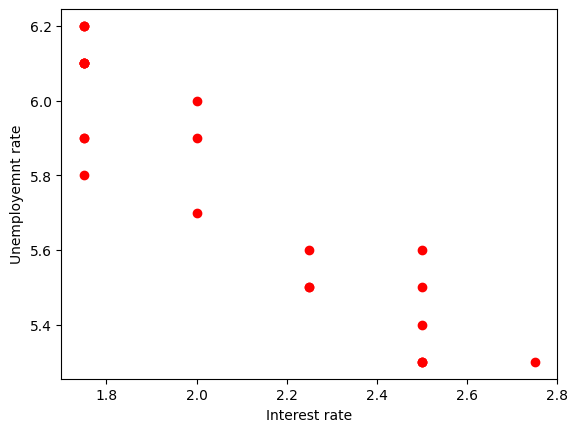

In [17]:
plt.scatter(df_index['interest_rate'], df_index['unemployment_rate'], color='red')
plt.xlabel('Interest rate')
plt.ylabel('Unemployemnt rate')

## independent and dependent features

In [18]:
X=df_index[['interest_rate','unemployment_rate']]
y=df_index['index_price']

In [19]:
X

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4
5,2.50,5.6
6,2.50,5.5
7,2.25,5.5
8,2.25,5.5
9,2.25,5.6


## train test split

In [21]:
from sklearn.model_selection import train_test_split

In [39]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.25, random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

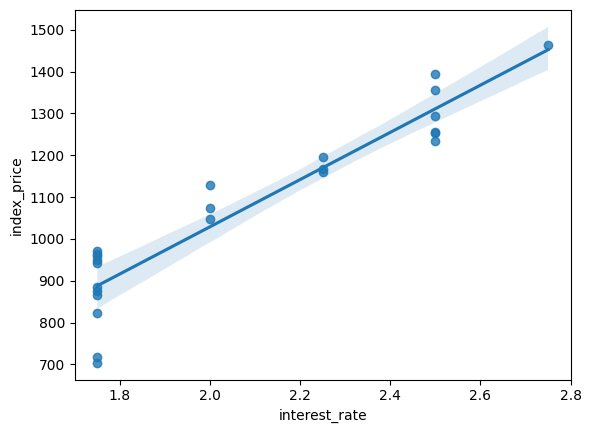

In [40]:
sns.regplot(x=df_index['interest_rate'], y=df_index['index_price'])

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

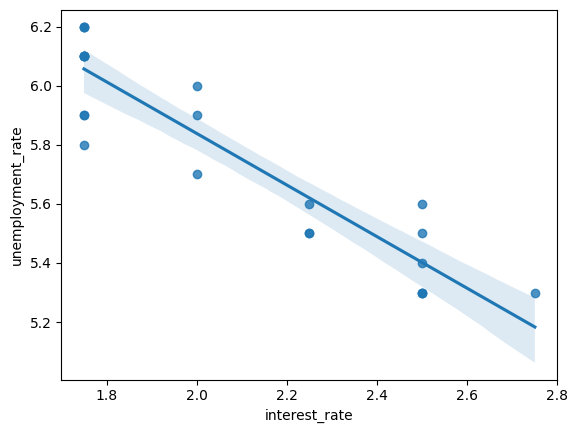

In [26]:
sns.regplot(x=df_index['interest_rate'], y=df_index['unemployment_rate'])

<Axes: xlabel='unemployment_rate', ylabel='index_price'>

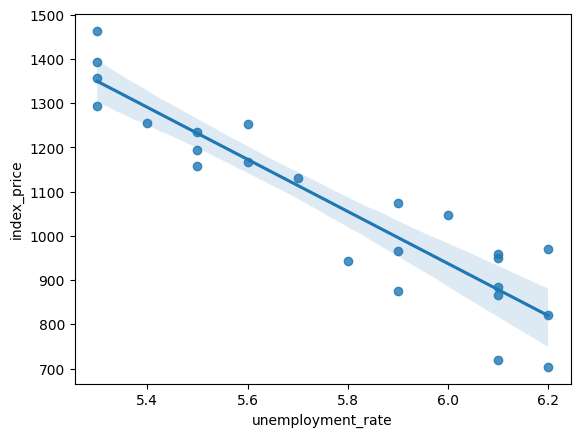

In [27]:
sns.regplot(x=df_index['unemployment_rate'], y=df_index['index_price'])

In [28]:
from sklearn.preprocessing import StandardScaler

In [29]:
scaler = StandardScaler()

In [41]:
type(X_test)

pandas.core.frame.DataFrame

In [32]:
type(X_train)

numpy.ndarray

In [42]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [43]:
X_test

array([[ 0.36115756, -0.82078268],
       [-1.08347268,  1.33377186],
       [ 1.8057878 , -1.43636969],
       [-1.08347268,  1.02597835],
       [-0.36115756,  0.41039134],
       [ 0.36115756, -0.51298918]])

In [44]:
from sklearn.linear_model import LinearRegression

In [45]:
regression = LinearRegression()

In [46]:
regression.fit(X_train, y_train)

LinearRegression()

In [47]:
from sklearn.model_selection import cross_val_score

In [48]:
validation_score = cross_val_score(regression, X_train, y_train, scoring='neg_mean_squared_error', cv=3)

In [49]:
validation_score

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [50]:
np.mean(validation_score)

np.float64(-5914.828180162386)

## prediction

In [52]:
y_pred = regression.predict(X_test)

In [55]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [56]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [57]:
mse

8108.567426306604

## Assumptions

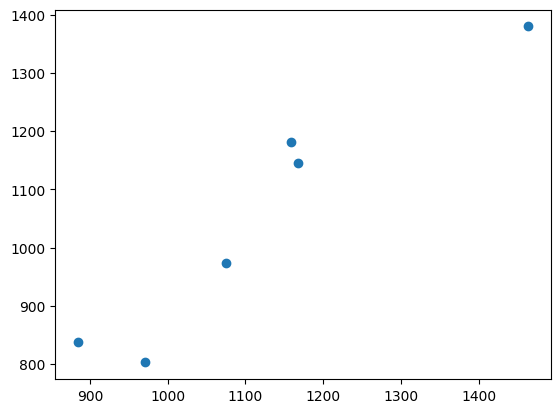

In [58]:
plt.scatter(y_test, y_pred)

In [59]:
residuals = y_test-y_pred

In [60]:
residuals

,index_price
8,-21.746681
16,168.257203
0,84.165430
18,45.474004
11,101.146860
9,22.036518


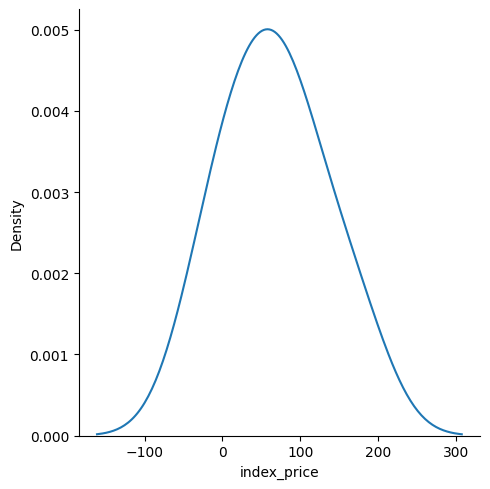

In [62]:
sns.displot(residuals,kind='kde')

## scatter plot w.r.t predictions and residuals


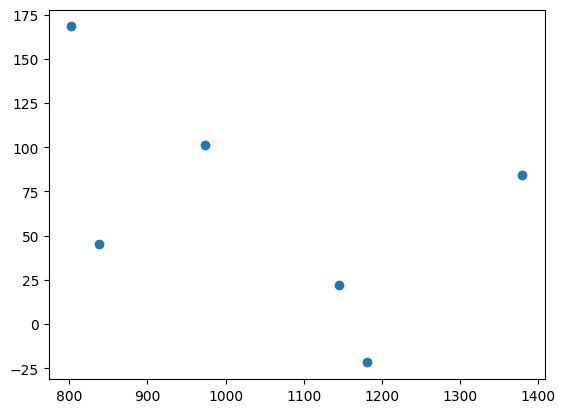

In [64]:
plt.scatter(y_pred,residuals) ## if it follows a pattern, there's a problem, if it dosen't follow a pattern there's no problem

In [65]:
import statsmodels.api as sm

In [66]:
model = sm.OLS(y_train,X_train).fit()

In [67]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Mon, 20 Jul 2026   Prob (F-statistic):                       0.754
Time:                        19:07:39   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [68]:
print(regression.coef_)

[  88.27275507 -116.25716066]
